In [7]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

sns.set_theme(style="whitegrid")

# 한글깨짐 해결
plt.rcParams["font.family"] = "Malgun Gothic"
plt.rcParams["axes.unicode_minus"] = False

df = pd.read_csv('../data/22_열처리.csv')

df['timestamp'] = pd.to_datetime(df['timestamp'])
df = df.set_index('timestamp').sort_index()

## 실습 3. 창 크기 3종 비교
창 크기를 바꿔 매끈함과 반응성의 맞교환 비교

목표
- 창 크기를 5·10·30으로 바꿔 매끈함과 반응성의 맞교환을 비교

단계
- 세 가지 창 크기로 이동평균을 각각 구하기
- 세 이동평균을 한 그래프에 겹쳐 그리기
- 창이 클수록 매끄럽지만 반응이 느려짐을 확인

예상 결과
- 창이 클수록 곡선이 매끄럽고 앞쪽 빈 구간이 늘어남

(1250, 7)


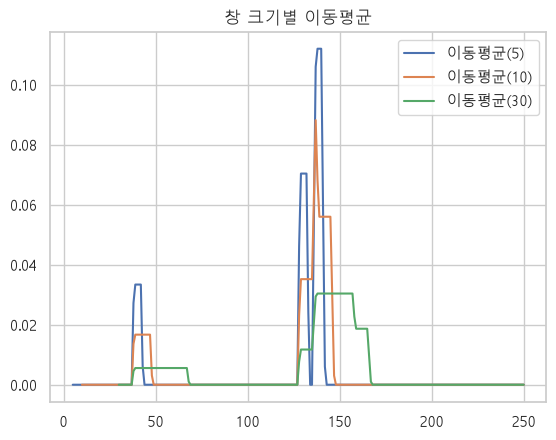

In [8]:
# 파일 불러와 크기와 엔진 목록 확인
df = pd.read_csv("23_전기Panel.csv")
print(df.shape) # (1250, 7)

eng2 = df[df['설비번호'] == 2].copy().sort_values('시퀀스').reset_index(drop=True)

for w in [5, 10, 30]:
    eng2[f'이동평균{w}'] = eng2['컨베이어전류'].rolling(window=w).mean()
    plt.plot(eng2['시퀀스'], eng2[f'이동평균{w}'], label=f'이동평균({w})')

plt.legend()
plt.title('창 크기별 이동평균')
plt.show()